In [1]:
import matplotlib.pyplot as plt
from lqg import xcorr
import jax.numpy as jnp
from jax import random

from cppp.models import CorrelatedObservationBoundedActor, CorrelatedObservationJerkBoundedActor

/homes/ds2181/cpp-proprioception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


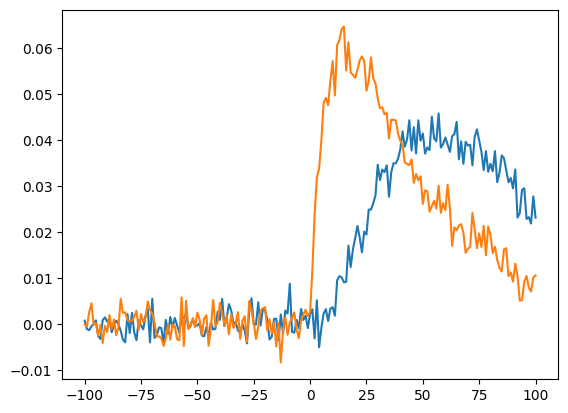

In [2]:
for model in [
    CorrelatedObservationJerkBoundedActor(
        T=1000,
        dt=1 / 120.0,
        sigma_target=jnp.array([8.0, 8.0]),
        sigma_cursor=jnp.array([8.0, 8.0]),
        corr_chol=jnp.eye(2),
        action_variability=jnp.array([.25, 0.25]),
        action_cost=jnp.array([0.01, 0.01]),
        jerk_cost=0.1,
        process_noise=1.0,
    ),
    CorrelatedObservationBoundedActor(
        T=1000,
        dt=1 / 120.0,
        sigma_target=jnp.array([8.0, 8.0]),
        sigma_cursor=jnp.array([8.0, 8.0]),
        corr_chol=jnp.eye(2),
        action_variability=jnp.array([0.25, 0.25]),
        action_cost=jnp.array([0.1, 0.1]),
        process_noise=1.0,
    ),
]:
    x = model.simulate(rng_key=random.PRNGKey(0), n=120)

    vels = jnp.diff(x, axis=-2)

    lags, correls = xcorr(vels[..., 1], vels[..., 0], maxlags=100)

    plt.plot(lags, correls.mean(axis=0))


In [5]:
jnp.eye(2) * jnp.array([1., 2.])

Array([[1., 0.],
       [0., 2.]], dtype=float32)

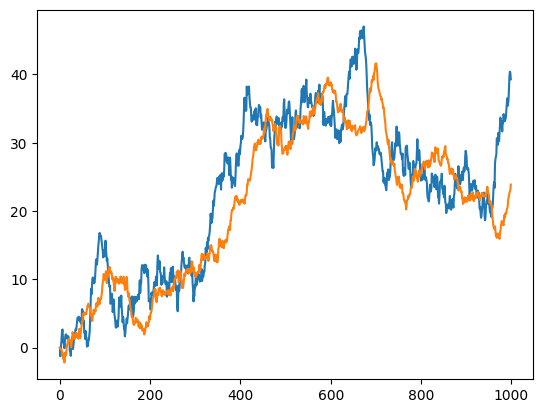